DEVICE: cuda
Class counts (train/val/test): [ 620  938 1011] [209 212 222] [209 266 328]
Class weights: [1.31912488 0.87191623 0.80895888]
Epoch 001 | train_loss=1.1018 | val_loss=1.1042 | val_acc=0.3235 | val_bacc=0.3151 | wait=0/15
Epoch 002 | train_loss=1.0978 | val_loss=1.1044 | val_acc=0.3328 | val_bacc=0.3229 | wait=1/15
Epoch 003 | train_loss=1.0960 | val_loss=1.1054 | val_acc=0.3577 | val_bacc=0.3469 | wait=2/15
Epoch 004 | train_loss=1.0947 | val_loss=1.1065 | val_acc=0.3577 | val_bacc=0.3469 | wait=3/15
Epoch 005 | train_loss=1.0937 | val_loss=1.1075 | val_acc=0.3437 | val_bacc=0.3334 | wait=4/15
Epoch 006 | train_loss=1.0927 | val_loss=1.1086 | val_acc=0.3468 | val_bacc=0.3367 | wait=5/15
Epoch 007 | train_loss=1.0919 | val_loss=1.1094 | val_acc=0.3468 | val_bacc=0.3372 | wait=6/15
Epoch 008 | train_loss=1.0911 | val_loss=1.1103 | val_acc=0.3406 | val_bacc=0.3316 | wait=7/15
Epoch 009 | train_loss=1.0902 | val_loss=1.1109 | val_acc=0.3390 | val_bacc=0.3303 | wait=8/15
Epoch 

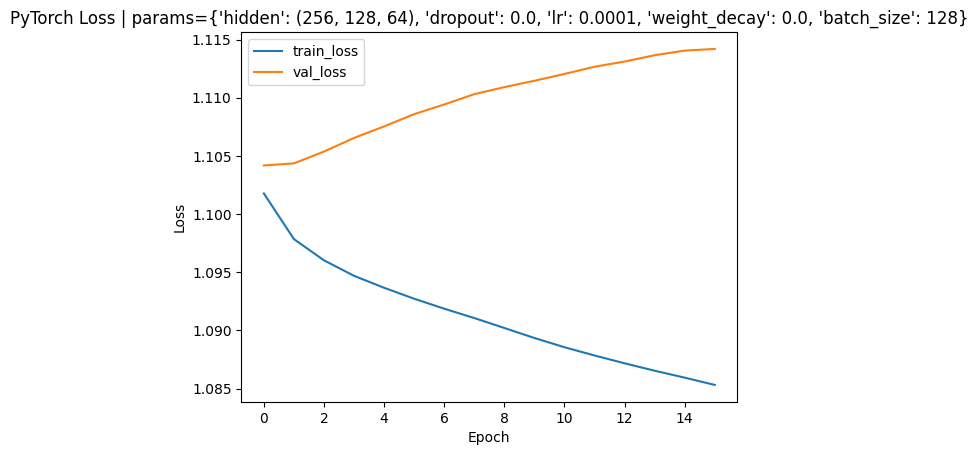

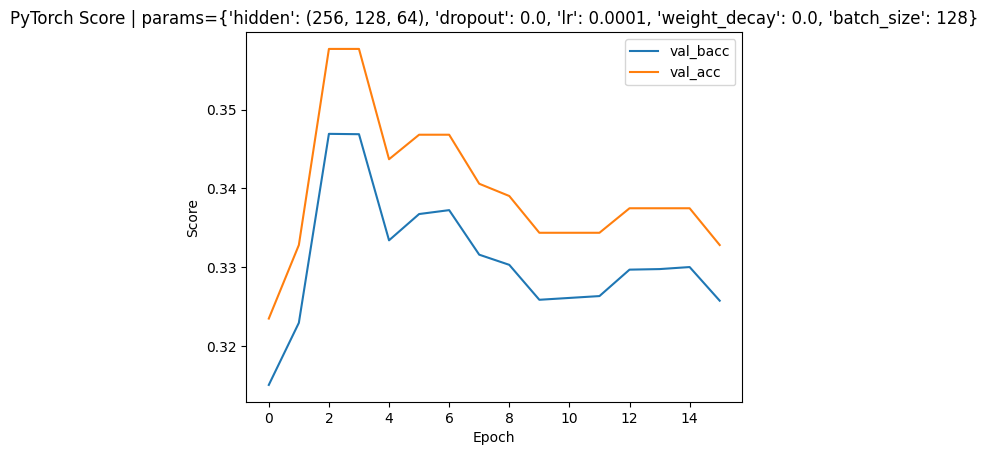

Pred distribution: [  4  30 769]
True distribution: [209 266 328]

===== PyTorch MLP (7-day ahead) TEST =====

Confusion Matrix (rows=true, cols=pred):
[[  2  12 195]
 [  0  11 255]
 [  2   7 319]]

Accuracy: 0.41344956413449563
Balanced Accuracy: 0.34116124568627776

Per-class PR/RC/F1:
  0 (Down): P=0.500 R=0.010 F1=0.019 Support=209
  1 (Sideway): P=0.367 R=0.041 F1=0.074 Support=266
  2 (Up): P=0.415 R=0.973 F1=0.582 Support=328

Macro Avg: P=0.427 R=0.341 F1=0.225


In [4]:
import os
import pickle
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# ============================================================
# Config
# ============================================================
CSV_PATH = "../CLASSIFY-SnP_daily_update_AMZN_features_with_target.csv"
FEATURES = [
    'ma_gap_20', 'ma_gap_10', 'vol_10',
    'ret_2', 'ret_5',
    'ret_1',
    'ret_4',
    'vol_20',
    'ret_3'
]

TRAIN_RATIO = 0.8
VAL_RATIO_IN_TRAIN = 0.2

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ----- Label -----
HORIZON = 7
PRICE_COL_CANDIDATES = ["Close", "Adj Close", "close", "adj_close"]
SIDEWAY_THRESHOLD = 0.02
CLASS_LABELS = {0: "Down", 1: "Sideway", 2: "Up"}

# ----- Device / Loader -----
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# ----- Fixed hyperparameters -----
PARAMS = {
    "hidden": (256, 128, 64),
    "dropout": 0.0,
    "lr": 1e-4,
    "weight_decay": 0.0,
    "batch_size": 128,
}

BATCH_SIZE_TEST = 256

# ----- Train control -----
EPOCHS = 200
PATIENCE = 15
MIN_DELTA = 1e-4

# Windows + Jupyter
NUM_WORKERS = 2
PIN_MEMORY = True

# ----- Checkpoint -----
CKPT_SINGLE = "ckpt_single_best.pkl"

# ============================================================
# Helpers
# ============================================================
def eval_report(name, y_true, y_pred, K=3):
    print(f"\n===== {name} =====")
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(K))
    print("\nConfusion Matrix (rows=true, cols=pred):")
    print(cm)

    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    pr, rc, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=np.arange(K), zero_division=0
    )
    macro_pr, macro_rc, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    print("\nAccuracy:", acc)
    print("Balanced Accuracy:", bacc)
    print("\nPer-class PR/RC/F1:")
    for c in range(K):
        print(f"  {c} ({CLASS_LABELS[c]}): P={pr[c]:.3f} R={rc[c]:.3f} F1={f1[c]:.3f} Support={sup[c]}")
    print(f"\nMacro Avg: P={macro_pr:.3f} R={macro_rc:.3f} F1={macro_f1:.3f}")

def evaluate_loader_loss_acc(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)

            pred = torch.argmax(logits, dim=1)
            correct += (pred == yb).sum().item()
            total += xb.size(0)

    avg_loss = total_loss / max(total, 1)
    acc = correct / max(total, 1)
    return avg_loss, acc

def evaluate_loader_bacc(model, loader, device):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = torch.argmax(model(xb), dim=1).cpu().numpy()
            ys.append(yb.numpy())
            ps.append(pred)
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    return balanced_accuracy_score(y_true, y_pred)

def save_ckpt(path, payload):
    with open(path, "wb") as f:
        pickle.dump(payload, f)

def load_ckpt(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# ============================================================
# 1) Load data + sort
# ============================================================
df = pd.read_csv(CSV_PATH)

if "Date" in df.columns:
    d = pd.to_datetime(df["Date"], errors="coerce")
    if d.notna().all():
        df = df.loc[d.sort_values().index].reset_index(drop=True)

missing_feat = [c for c in FEATURES if c not in df.columns]
if missing_feat:
    raise ValueError(f"Missing FEATURES columns: {missing_feat}")

price_col = next((c for c in PRICE_COL_CANDIDATES if c in df.columns), None)
if price_col is None:
    raise ValueError(f"Need price column in {PRICE_COL_CANDIDATES}")

# ============================================================
# 2) Build 7-day label
# ============================================================
price = df[price_col].astype(float)
future_price = price.shift(-HORIZON)
future_ret = (future_price / price) - 1.0

y = np.full(len(df), np.nan)
y[future_ret >  SIDEWAY_THRESHOLD] = 2
y[np.abs(future_ret) <= SIDEWAY_THRESHOLD] = 1
y[future_ret < -SIDEWAY_THRESHOLD] = 0

data = df[FEATURES].copy()
data["y"] = y
data = data.dropna().reset_index(drop=True)

X = data[FEATURES].to_numpy(np.float32)
y = data["y"].to_numpy(np.int64)

# ============================================================
# 3) Strict split
# ============================================================
N = len(X)
split_test = int(N * TRAIN_RATIO)

X_train_full, y_train_full = X[:split_test], y[:split_test]
X_test, y_test = X[split_test:], y[split_test:]

n_train_full = len(X_train_full)
split_val = int(n_train_full * (1 - VAL_RATIO_IN_TRAIN))

X_train, y_train = X_train_full[:split_val], y_train_full[:split_val]
X_val, y_val = X_train_full[split_val:], y_train_full[split_val:]

print("Class counts (train/val/test):",
      np.bincount(y_train, minlength=3),
      np.bincount(y_val, minlength=3),
      np.bincount(y_test, minlength=3))

# ============================================================
# 4) Standardize (no leakage)
# ============================================================
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_val_sc   = scaler.transform(X_val).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)

# ============================================================
# 5) Torch datasets
# ============================================================
train_ds = TensorDataset(torch.from_numpy(X_train_sc), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val_sc),   torch.from_numpy(y_val))
test_ds  = TensorDataset(torch.from_numpy(X_test_sc),  torch.from_numpy(y_test))

def make_loader(ds, batch_size):
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(PIN_MEMORY and DEVICE == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
    )

# ============================================================
# 6) Model
# ============================================================
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=(64, 32), dropout=0.2, n_classes=3):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, n_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# ============================================================
# 7) Class weights
# ============================================================
train_counts = np.bincount(y_train, minlength=3)
class_weights = (train_counts.sum() / (train_counts + 1e-9))
class_weights = class_weights / class_weights.mean()
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights:", class_weights)

# ============================================================
# 8) Train single model (early stop by val_loss, best ckpt by val_bacc)
# ============================================================
train_loader = make_loader(train_ds, PARAMS["batch_size"])
val_loader   = make_loader(val_ds,   PARAMS["batch_size"])

best_model = MLP(
    in_dim=X_train_sc.shape[1],
    hidden=PARAMS["hidden"],
    dropout=PARAMS["dropout"],
    n_classes=3
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = torch.optim.Adam(
    best_model.parameters(),
    lr=PARAMS["lr"],
    weight_decay=PARAMS["weight_decay"]
)

hist_train_loss = []
hist_val_loss = []
hist_val_acc = []
hist_val_bacc = []

best_state = None
best_val_bacc = -1.0
best_val_loss_for_es = float("inf")
wait = 0

for epoch in range(1, EPOCHS + 1):
    best_model.train()
    total_loss = 0.0
    total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = best_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)

    train_loss = total_loss / max(total, 1)
    val_loss, val_acc = evaluate_loader_loss_acc(best_model, val_loader, criterion, DEVICE)
    val_bacc = evaluate_loader_bacc(best_model, val_loader, DEVICE)

    hist_train_loss.append(train_loss)
    hist_val_loss.append(val_loss)
    hist_val_acc.append(val_acc)
    hist_val_bacc.append(val_bacc)

    # best checkpoint by val_bacc
    if val_bacc > best_val_bacc:
        best_val_bacc = val_bacc
        best_state = {k: v.detach().cpu().clone() for k, v in best_model.state_dict().items()}
        save_ckpt(CKPT_SINGLE, {
            "best_val_bacc": float(best_val_bacc),
            "params": PARAMS,
            "state": best_state,
        })

    # early stop by val_loss
    improved = (best_val_loss_for_es - val_loss) > MIN_DELTA
    if improved:
        best_val_loss_for_es = val_loss
        wait = 0
    else:
        wait += 1

    print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_bacc={val_bacc:.4f} | wait={wait}/{PATIENCE}")

    if wait >= PATIENCE:
        break

print("\nBest val_bacc:", best_val_bacc)

# restore best by val_bacc
if best_state is not None:
    best_model.load_state_dict(best_state)
    print("Restored best state | best_val_bacc =", best_val_bacc)

# ============================================================
# Plot curves
# ============================================================
plt.figure()
plt.plot(hist_train_loss, label="train_loss")
plt.plot(hist_val_loss, label="val_loss")
plt.title(f"PyTorch Loss | params={PARAMS}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist_val_bacc, label="val_bacc")
plt.plot(hist_val_acc, label="val_acc")
plt.title(f"PyTorch Score | params={PARAMS}")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()

# ============================================================
# Test evaluation
# ============================================================
test_loader = make_loader(test_ds, BATCH_SIZE_TEST)

best_model.eval()
all_pred, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = best_model(xb)
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        all_pred.append(pred)
        all_true.append(yb.numpy())

y_pred = np.concatenate(all_pred)
y_true = np.concatenate(all_true)

print("Pred distribution:", np.bincount(y_pred, minlength=3))
print("True distribution:", np.bincount(y_true, minlength=3))

eval_report("PyTorch MLP (7-day ahead) TEST", y_true, y_pred, K=3)

Class counts (train/val/test): [ 620  938 1011] [209 212 222] [209 266 328]
Class weights: [1.3191249  0.87191623 0.8089589 ]
Epoch 001 | train_loss=1.2441 | val_loss=1.1469 | val_acc=0.3515 | val_bacc=0.3506 | wait=0/15
Epoch 002 | train_loss=1.1360 | val_loss=1.1521 | val_acc=0.3453 | val_bacc=0.3442 | wait=1/15
Epoch 003 | train_loss=1.1132 | val_loss=1.1351 | val_acc=0.3468 | val_bacc=0.3464 | wait=0/15
Epoch 004 | train_loss=1.0980 | val_loss=1.1340 | val_acc=0.3406 | val_bacc=0.3399 | wait=0/15
Epoch 005 | train_loss=1.0860 | val_loss=1.1309 | val_acc=0.3359 | val_bacc=0.3353 | wait=0/15
Epoch 006 | train_loss=1.0758 | val_loss=1.1311 | val_acc=0.3421 | val_bacc=0.3411 | wait=1/15
Epoch 007 | train_loss=1.0678 | val_loss=1.1301 | val_acc=0.3468 | val_bacc=0.3455 | wait=0/15
Epoch 008 | train_loss=1.0606 | val_loss=1.1293 | val_acc=0.3437 | val_bacc=0.3423 | wait=0/15
Epoch 009 | train_loss=1.0544 | val_loss=1.1284 | val_acc=0.3484 | val_bacc=0.3470 | wait=0/15
Epoch 010 | train_l

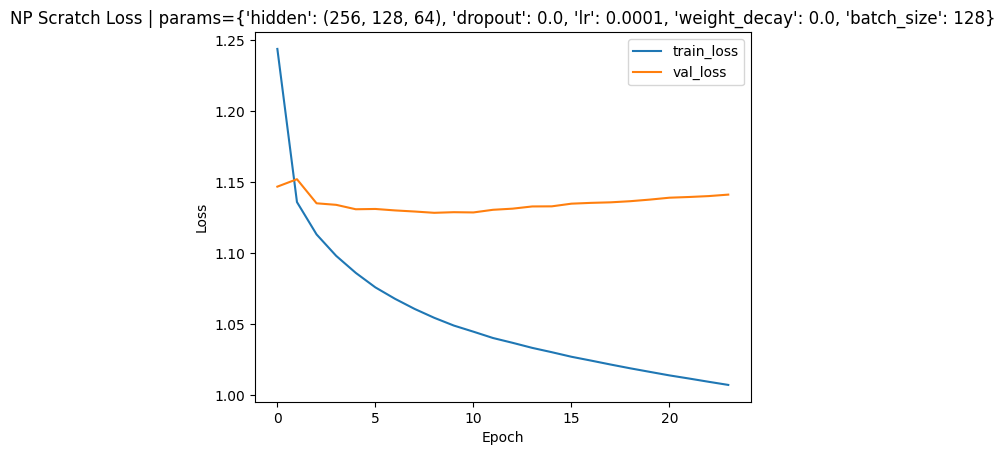

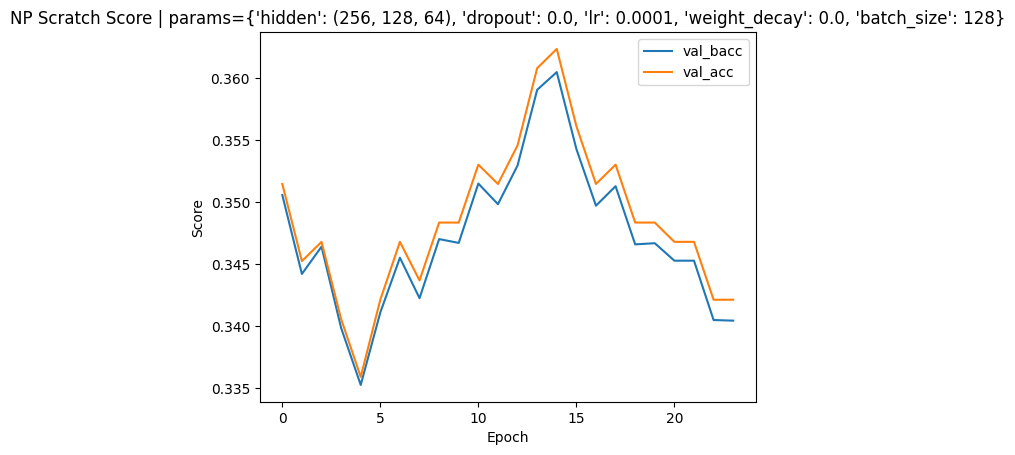

In [5]:
import os
import pickle
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support
)

import matplotlib.pyplot as plt

# ============================================================
# Config
# ============================================================
CSV_PATH = "../CLASSIFY-SnP_daily_update_AMZN_features_with_target.csv"
FEATURES = [
    'ma_gap_20', 'ma_gap_10', 'vol_10',
    'ret_2', 'ret_5',
    'ret_1',
    'ret_4',
    'vol_20',
    'ret_3'
]

TRAIN_RATIO = 0.8
VAL_RATIO_IN_TRAIN = 0.2

SEED = 42
np.random.seed(SEED)

# ----- Label -----
HORIZON = 7
PRICE_COL_CANDIDATES = ["Close", "Adj Close", "close", "adj_close"]
SIDEWAY_THRESHOLD = 0.02
CLASS_LABELS = {0: "Down", 1: "Sideway", 2: "Up"}
K = 3

# ----- Fixed hyperparameters -----
PARAMS = {
    "hidden": (256, 128, 64),
    "dropout": 0.0,
    "lr": 1e-4,
    "weight_decay": 0.0,
    "batch_size": 128
}

# ----- Train control -----
EPOCHS = 200
PATIENCE = 15
MIN_DELTA = 1e-4  # early stop on val_loss

BATCH_SIZE_EVAL = 256
BATCH_SIZE_TEST = 256

# ----- Checkpoint (single model) -----
NP_CKPT_SINGLE = "np_ckpt_single_best.pkl"

# ============================================================
# Helpers
# ============================================================
def eval_report(name, y_true, y_pred, K=3):
    print(f"\n===== {name} =====")
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(K))
    print("\nConfusion Matrix (rows=true, cols=pred):")
    print(cm)

    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)

    pr, rc, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=np.arange(K), zero_division=0
    )
    macro_pr, macro_rc, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    print("\nAccuracy:", acc)
    print("Balanced Accuracy:", bacc)
    print("\nPer-class PR/RC/F1:")
    for c in range(K):
        print(f"  {c} ({CLASS_LABELS[c]}): P={pr[c]:.3f} R={rc[c]:.3f} F1={f1[c]:.3f} Support={sup[c]}")
    print(f"\nMacro Avg: P={macro_pr:.3f} R={macro_rc:.3f} F1={macro_f1:.3f}")

def np_save(path, payload):
    with open(path, "wb") as f:
        pickle.dump(payload, f)

def np_load(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# ============================================================
# NumPy blocks
# ============================================================
def relu(x):
    return np.maximum(0.0, x)

def relu_backward(dout, x):
    dx = dout.copy()
    dx[x <= 0.0] = 0.0
    return dx

def softmax(logits):
    z = logits - np.max(logits, axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / (np.sum(exp, axis=1, keepdims=True) + 1e-12)

def one_hot(y, K):
    oh = np.zeros((len(y), K), dtype=np.float32)
    oh[np.arange(len(y)), y] = 1.0
    return oh

def weighted_softmax_ce_loss_and_grad(logits, y, class_weights=None):
    B, K = logits.shape
    probs = softmax(logits)

    p_true = probs[np.arange(B), y]
    loss_vec = -np.log(p_true + 1e-12)

    if class_weights is not None:
        w = class_weights[y]
        loss = np.sum(w * loss_vec) / (np.sum(w) + 1e-12)
    else:
        loss = float(np.mean(loss_vec))

    y_oh = one_hot(y, K)
    dlogits = probs - y_oh

    if class_weights is not None:
        w = class_weights[y].reshape(-1, 1)
        dlogits = (dlogits * w) / (np.sum(w) + 1e-12)
    else:
        dlogits = dlogits / B

    return float(loss), dlogits.astype(np.float32)

# ============================================================
# AdamScratch (coupled weight_decay like torch.optim.Adam)
# ============================================================
class AdamScratch:
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.0):
        self.params = params
        self.lr = float(lr)
        self.beta1 = float(betas[0])
        self.beta2 = float(betas[1])
        self.eps = float(eps)
        self.weight_decay = float(weight_decay)
        self.t = 0
        self.m = [np.zeros_like(p) for p in self.params]
        self.v = [np.zeros_like(p) for p in self.params]

    def step(self, grads):
        self.t += 1
        b1, b2, lr, eps, wd = self.beta1, self.beta2, self.lr, self.eps, self.weight_decay

        for i, (p, g) in enumerate(zip(self.params, grads)):
            if wd != 0.0:
                g = g + wd * p  # coupled weight decay

            self.m[i] = b1 * self.m[i] + (1 - b1) * g
            self.v[i] = b2 * self.v[i] + (1 - b2) * (g * g)

            m_hat = self.m[i] / (1 - b1**self.t)
            v_hat = self.v[i] / (1 - b2**self.t)

            p -= lr * m_hat / (np.sqrt(v_hat) + eps)

# ============================================================
# MLP NumPy + Dropout
# ============================================================
class MLP_Numpy_Dropout:
    def __init__(self, in_dim, hidden=(256,128,64), dropout=0.0, out_dim=3, seed=42):
        self.rng = np.random.default_rng(seed)
        dims = [in_dim] + list(hidden) + [out_dim]

        self.W, self.b = [], []
        for i in range(len(dims) - 1):
            fan_in = dims[i]
            fan_out = dims[i + 1]
            w = self.rng.normal(0.0, np.sqrt(2.0 / fan_in), size=(fan_in, fan_out)).astype(np.float32)
            b = np.zeros((fan_out,), dtype=np.float32)
            self.W.append(w)
            self.b.append(b)

        self.dropout = float(dropout)
        self.cache = None

    def forward(self, x, training=True):
        a = x
        preacts, activs, drop_masks = [], [x], []

        for i in range(len(self.W) - 1):
            z = a @ self.W[i] + self.b[i]
            a = relu(z)

            if training and self.dropout > 0.0:
                keep_prob = 1.0 - self.dropout
                mask = (self.rng.random(a.shape) < keep_prob).astype(np.float32) / keep_prob
                a = a * mask
            else:
                mask = None

            preacts.append(z)
            activs.append(a)
            drop_masks.append(mask)

        logits = a @ self.W[-1] + self.b[-1]
        self.cache = (preacts, activs, drop_masks)
        return logits

    def backward(self, dlogits):
        preacts, activs, drop_masks = self.cache
        L = len(self.W)

        dW = [None] * L
        db = [None] * L

        a_last = activs[-1]
        dW[-1] = a_last.T @ dlogits
        db[-1] = np.sum(dlogits, axis=0)

        da = dlogits @ self.W[-1].T

        for i in reversed(range(L - 1)):
            mask = drop_masks[i]
            if mask is not None:
                da = da * mask

            z = preacts[i]
            dz = relu_backward(da, z)

            a_prev = activs[i]
            dW[i] = a_prev.T @ dz
            db[i] = np.sum(dz, axis=0)

            da = dz @ self.W[i].T

        dW = [g.astype(np.float32) for g in dW]
        db = [g.astype(np.float32) for g in db]
        return dW, db

    def params_list(self):
        return self.W + self.b

    def grads_list(self, dW, db):
        return dW + db

    def get_state(self):
        return {"W": [w.copy() for w in self.W], "b": [b.copy() for b in self.b]}

    def set_state(self, state):
        self.W = [w.copy() for w in state["W"]]
        self.b = [b.copy() for b in state["b"]]

# ============================================================
# Mini-batch (shuffle=False)
# ============================================================
def iterate_minibatches(X, y, batch_size, shuffle=False, seed=42):
    n = len(X)
    idx = np.arange(n)

    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(idx)

    for start in range(0, n, batch_size):
        batch_idx = idx[start:start + batch_size]
        yield X[batch_idx], y[batch_idx]

def eval_numpy_loss_acc_bacc(model, X, y, class_weights, batch_size=256):
    losses, preds = [], []
    for xb, yb in iterate_minibatches(X, y, batch_size):
        logits = model.forward(xb, training=False)
        loss, _ = weighted_softmax_ce_loss_and_grad(logits, yb, class_weights)
        losses.append(loss)
        preds.append(np.argmax(logits, axis=1))
    y_pred = np.concatenate(preds)
    return float(np.mean(losses)), float(accuracy_score(y, y_pred)), float(balanced_accuracy_score(y, y_pred))

def predict_numpy(model, X, batch_size=256):
    preds = []
    dummy_y = np.zeros((len(X),), dtype=np.int64)
    for xb, _ in iterate_minibatches(X, dummy_y, batch_size):
        logits = model.forward(xb, training=False)
        preds.append(np.argmax(logits, axis=1))
    return np.concatenate(preds)

# ============================================================
# Load + label + split
# ============================================================
df = pd.read_csv(CSV_PATH)

if "Date" in df.columns:
    d = pd.to_datetime(df["Date"], errors="coerce")
    if d.notna().all():
        df = df.loc[d.sort_values().index].reset_index(drop=True)

missing_feat = [c for c in FEATURES if c not in df.columns]
if missing_feat:
    raise ValueError(f"Missing FEATURES columns: {missing_feat}")

price_col = next((c for c in PRICE_COL_CANDIDATES if c in df.columns), None)
if price_col is None:
    raise ValueError(f"Need price column in {PRICE_COL_CANDIDATES}")

price = df[price_col].astype(float)
future_price = price.shift(-HORIZON)
future_ret = (future_price / price) - 1.0

y_all = np.full(len(df), np.nan)
y_all[future_ret >  SIDEWAY_THRESHOLD] = 2
y_all[np.abs(future_ret) <= SIDEWAY_THRESHOLD] = 1
y_all[future_ret < -SIDEWAY_THRESHOLD] = 0

data = df[FEATURES].copy()
data["y"] = y_all
data = data.dropna().reset_index(drop=True)

X = data[FEATURES].to_numpy(np.float32)
y = data["y"].to_numpy(np.int64)

N = len(X)
split_test = int(N * TRAIN_RATIO)

X_train_full, y_train_full = X[:split_test], y[:split_test]
X_test, y_test = X[split_test:], y[split_test:]

n_train_full = len(X_train_full)
split_val = int(n_train_full * (1 - VAL_RATIO_IN_TRAIN))

X_train, y_train = X_train_full[:split_val], y_train_full[:split_val]
X_val, y_val = X_train_full[split_val:], y_train_full[split_val:]

print("Class counts (train/val/test):",
      np.bincount(y_train, minlength=3),
      np.bincount(y_val, minlength=3),
      np.bincount(y_test, minlength=3))

# standardize
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_val_sc   = scaler.transform(X_val).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)

# class weights
train_counts = np.bincount(y_train, minlength=3).astype(np.float32)
class_weights = (train_counts.sum() / (train_counts + 1e-9))
class_weights = class_weights / class_weights.mean()
print("Class weights:", class_weights)

# ============================================================
# Train single model (early stop by val_loss, best ckpt by val_bacc)
# ============================================================
np_model = MLP_Numpy_Dropout(
    in_dim=X_train_sc.shape[1],
    hidden=PARAMS["hidden"],
    dropout=PARAMS["dropout"],
    out_dim=K,
    seed=SEED
)

np_optim = AdamScratch(
    params=np_model.params_list(),
    lr=PARAMS["lr"],
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=PARAMS["weight_decay"]
)

hist_train_loss = []
hist_val_loss = []
hist_val_acc = []
hist_val_bacc = []

best_state_by_bacc = None
best_val_bacc = -1.0

best_val_loss_for_earlystop = float("inf")
wait = 0

for epoch in range(1, EPOCHS + 1):
    # train epoch
    epoch_losses = []
    for xb, yb in iterate_minibatches(X_train_sc, y_train, PARAMS["batch_size"]):
        logits = np_model.forward(xb, training=True)
        loss, dlogits = weighted_softmax_ce_loss_and_grad(logits, yb, class_weights)
        dW, db = np_model.backward(dlogits)
        grads = np_model.grads_list(dW, db)
        np_optim.step(grads)
        epoch_losses.append(loss)

    train_loss = float(np.mean(epoch_losses)) if epoch_losses else float("nan")
    val_loss, val_acc, val_bacc = eval_numpy_loss_acc_bacc(np_model, X_val_sc, y_val, class_weights, batch_size=BATCH_SIZE_EVAL)

    hist_train_loss.append(train_loss)
    hist_val_loss.append(val_loss)
    hist_val_acc.append(val_acc)
    hist_val_bacc.append(val_bacc)

    # best checkpoint by val_bacc
    if val_bacc > best_val_bacc:
        best_val_bacc = val_bacc
        best_state_by_bacc = np_model.get_state()
        np_save(NP_CKPT_SINGLE, {
            "best_val_bacc": float(best_val_bacc),
            "params": PARAMS,
            "state": best_state_by_bacc,
        })

    # early stop by val_loss
    improved = (best_val_loss_for_earlystop - val_loss) > MIN_DELTA
    if improved:
        best_val_loss_for_earlystop = val_loss
        wait = 0
    else:
        wait += 1

    print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_bacc={val_bacc:.4f} | wait={wait}/{PATIENCE}")

    if wait >= PATIENCE:
        break

print("\nBest val_bacc:", best_val_bacc)

# restore best by val_bacc
if os.path.exists(NP_CKPT_SINGLE):
    ckpt = np_load(NP_CKPT_SINGLE)
    np_model.set_state(ckpt["state"])
    print("Loaded best checkpoint from:", NP_CKPT_SINGLE, "| best_val_bacc =", ckpt["best_val_bacc"])

# ============================================================
# Test eval
# ============================================================
np_y_pred = predict_numpy(np_model, X_test_sc, batch_size=BATCH_SIZE_TEST)
np_y_true = y_test.copy()

print("Pred distribution:", np.bincount(np_y_pred, minlength=3))
print("True distribution:", np.bincount(np_y_true, minlength=3))

eval_report("NP Scratch Single MLP (7-day ahead) TEST", np_y_true, np_y_pred, K=3)

# ============================================================
# Plot
# ============================================================
plt.figure()
plt.plot(hist_train_loss, label="train_loss")
plt.plot(hist_val_loss, label="val_loss")
plt.title(f"NP Scratch Loss | params={PARAMS}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist_val_bacc, label="val_bacc")
plt.plot(hist_val_acc, label="val_acc")
plt.title(f"NP Scratch Score | params={PARAMS}")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()


===== PyTorch BEST =====
Accuracy: 0.41344956413449563
Balanced Accuracy: 0.34116124568627776
Precision macro: 0.42716370466695563
Recall macro: 0.34116124568627776
F1 macro: 0.22489660369216646
Precision weighted: 0.42104078712198134
Recall weighted: 0.41344956413449563
F1 weighted: 0.26706775609084205

Full report:
              precision    recall  f1-score   support

        Down       0.50      0.01      0.02       209
     Sideway       0.37      0.04      0.07       266
          Up       0.41      0.97      0.58       328

    accuracy                           0.41       803
   macro avg       0.43      0.34      0.22       803
weighted avg       0.42      0.41      0.27       803


===== Scratch NumPy =====
Accuracy: 0.3574097135740971
Balanced Accuracy: 0.35180801227014324
Precision macro: 0.35251112523839795
Recall macro: 0.35180801227014324
F1 macro: 0.35099123977139274
Precision weighted: 0.36531276942235846
Recall weighted: 0.3574097135740971
F1 weighted: 0.360160327074

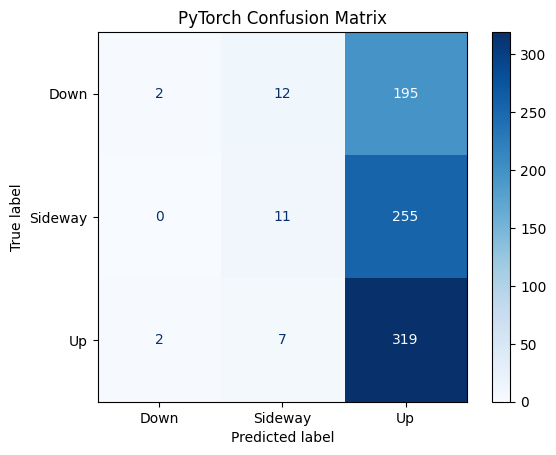

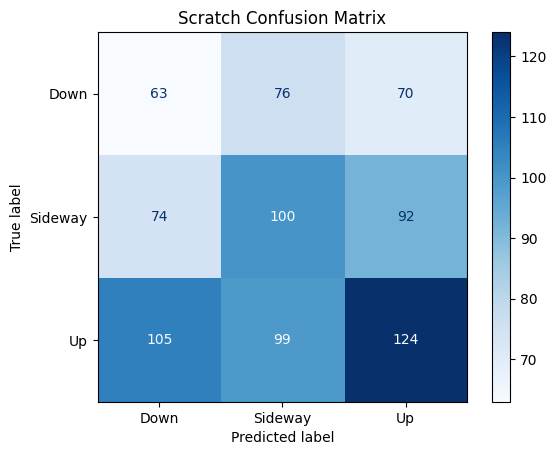

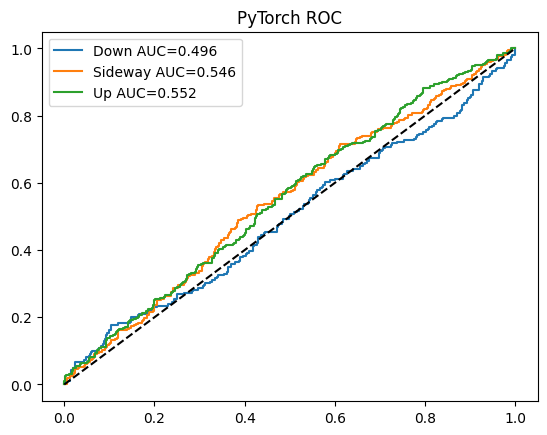

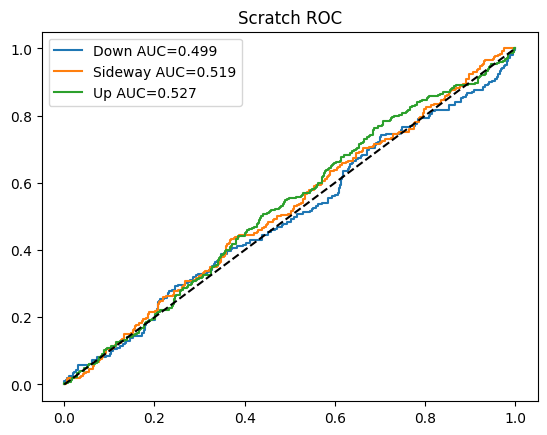

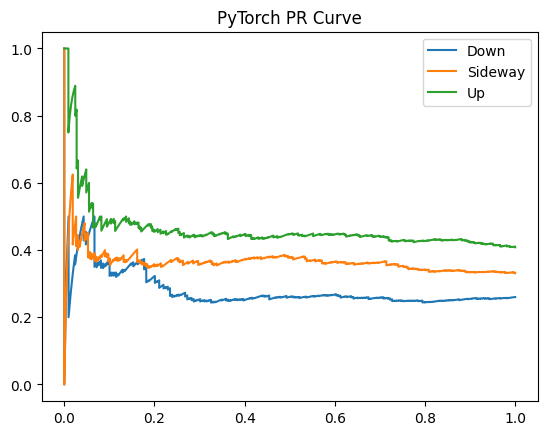

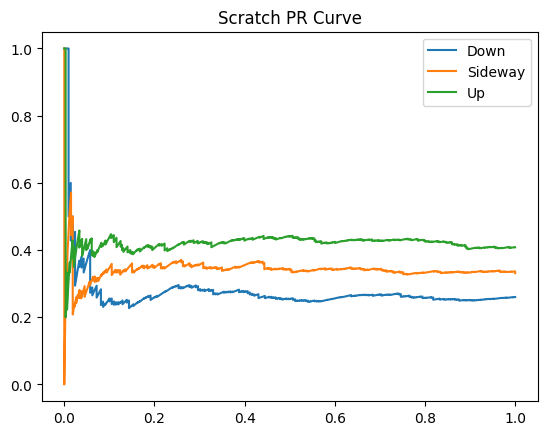

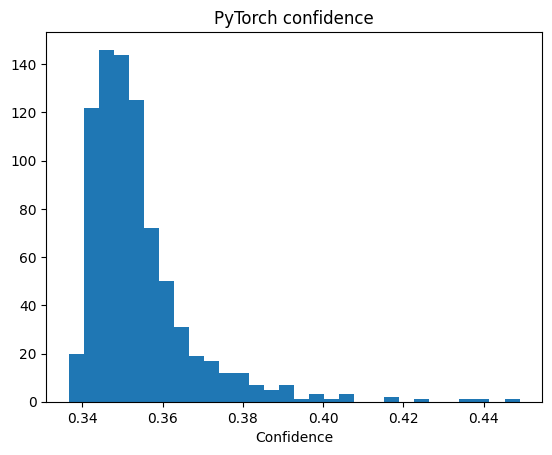

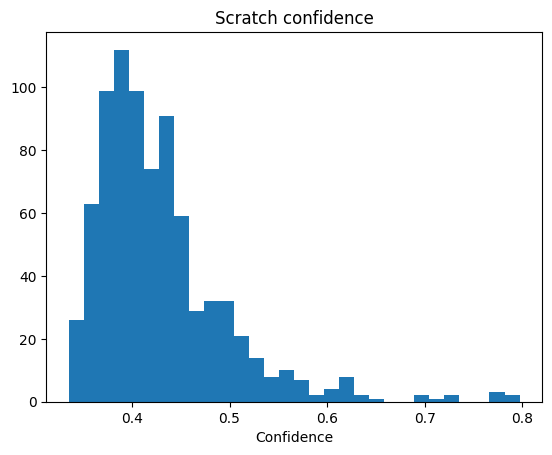

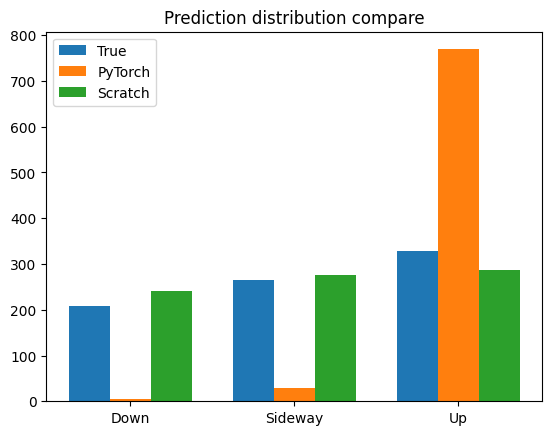

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
)

from sklearn.preprocessing import label_binarize

# ============================================================
# Get probabilities and predictions
# ============================================================

def torch_predict_proba(model, loader, device):
    import torch
    model.eval()

    ys, ps, probs = [], [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)

            prob = torch.softmax(logits, dim=1).cpu().numpy()
            pred = np.argmax(prob, axis=1)

            probs.append(prob)
            ps.append(pred)
            ys.append(yb.numpy())

    return np.concatenate(ys), np.concatenate(ps), np.concatenate(probs)


def numpy_predict_proba(np_model, X, y, batch_size=256):

    probs = []
    preds = []

    for xb, _ in iterate_minibatches(X, y, batch_size, shuffle=False):

        logits = np_model.forward(xb, training=False)
        prob = softmax(logits)

        probs.append(prob)
        preds.append(np.argmax(prob, axis=1))

    return y.copy(), np.concatenate(preds), np.concatenate(probs)


# ============================================================
# Metrics summary
# ============================================================

def print_metrics(name, y_true, y_pred):

    print(f"\n===== {name} =====")

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))

    print("Precision macro:", precision_score(y_true, y_pred, average="macro"))
    print("Recall macro:", recall_score(y_true, y_pred, average="macro"))
    print("F1 macro:", f1_score(y_true, y_pred, average="macro"))

    print("Precision weighted:", precision_score(y_true, y_pred, average="weighted"))
    print("Recall weighted:", recall_score(y_true, y_pred, average="weighted"))
    print("F1 weighted:", f1_score(y_true, y_pred, average="weighted"))

    print("\nFull report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=[CLASS_LABELS[i] for i in range(len(CLASS_LABELS))]
    ))


# ============================================================
# Confusion matrix plot
# ============================================================

def plot_confusion(y_true, y_pred, title):

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=[CLASS_LABELS[i] for i in range(len(CLASS_LABELS))]
    )

    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()
    plt.close("all")


# ============================================================
# ROC curve (multiclass one-vs-rest)
# ============================================================

def plot_multiclass_roc(y_true, probs, title):

    y_bin = label_binarize(y_true, classes=[0,1,2])

    plt.figure()

    for i in range(3):

        fpr, tpr, _ = roc_curve(y_bin[:,i], probs[:,i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{CLASS_LABELS[i]} AUC={roc_auc:.3f}")

    plt.plot([0,1],[0,1],'k--')
    plt.title(title)
    plt.legend()
    plt.show()
    plt.close("all")


# ============================================================
# Precision Recall curve
# ============================================================

def plot_pr_curve(y_true, probs, title):

    y_bin = label_binarize(y_true, classes=[0,1,2])

    plt.figure()

    for i in range(3):

        prec, rec, _ = precision_recall_curve(y_bin[:,i], probs[:,i])
        plt.plot(rec, prec, label=CLASS_LABELS[i])

    plt.title(title)
    plt.legend()
    plt.show()
    plt.close("all")


# ============================================================
# Confidence histogram
# ============================================================

def plot_confidence_hist(probs, title):

    conf = probs.max(axis=1)

    plt.figure()
    plt.hist(conf, bins=30)
    plt.title(title)
    plt.xlabel("Confidence")
    plt.show()
    plt.close("all")


# ============================================================
# Distribution compare
# ============================================================

def plot_distribution_compare(y_true, pred_torch, pred_np):

    x = np.arange(3)

    true_counts = np.bincount(y_true, minlength=3)
    torch_counts = np.bincount(pred_torch, minlength=3)
    np_counts = np.bincount(pred_np, minlength=3)

    width = 0.25

    plt.figure()

    plt.bar(x-width, true_counts, width, label="True")
    plt.bar(x, torch_counts, width, label="PyTorch")
    plt.bar(x+width, np_counts, width, label="Scratch")

    plt.xticks(x, [CLASS_LABELS[i] for i in range(3)])
    plt.legend()
    plt.title("Prediction distribution compare")

    plt.show()
    plt.close("all")


# ============================================================
# RUN ALL EVAL
# ============================================================

torch_true, torch_pred, torch_probs = torch_predict_proba(
    best_model,
    test_loader,
    DEVICE
)

np_true, np_pred, np_probs = numpy_predict_proba(
    np_model,
    X_test_sc,
    y_test
)


# metrics
print_metrics("PyTorch BEST", torch_true, torch_pred)
print_metrics("Scratch NumPy", np_true, np_pred)


# confusion
plot_confusion(torch_true, torch_pred, "PyTorch Confusion Matrix")
plot_confusion(np_true, np_pred, "Scratch Confusion Matrix")


# ROC
plot_multiclass_roc(torch_true, torch_probs, "PyTorch ROC")
plot_multiclass_roc(np_true, np_probs, "Scratch ROC")


# PR curve
plot_pr_curve(torch_true, torch_probs, "PyTorch PR Curve")
plot_pr_curve(np_true, np_probs, "Scratch PR Curve")


# confidence
plot_confidence_hist(torch_probs, "PyTorch confidence")
plot_confidence_hist(np_probs, "Scratch confidence")


# distribution compare
plot_distribution_compare(y_test, torch_pred, np_pred)